BƯỚC 1:

Bài toán: Classification

Mục tiêu:
Dự đoán sinh viên PASS hay FAIL dựa trên các yếu tố như:
- Thời gian học
- Điểm trước đó
- Tỷ lệ chuyên cần
- Hỗ trợ từ gia đình

Định nghĩa:
- PASS (1): FinalGrade >= 50
- FAIL (0): FinalGrade < 50

Metric:
- Accuracy
- Precision, Recall, F1-score

Lý do chọn Recall:
Quan trọng phát hiện sinh viên FAIL để hỗ trợ kịp thời

BƯỚC 2: THỰC HIỆN EDA

In [3]:
# 0. IMPORT THƯ VIỆN
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# 1. SETUP (style + folder lưu ảnh)
os.makedirs("../screenshots", exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['figure.figsize'] = [10, 6]


# 2. LOAD DATA

df = pd.read_csv("../data/student_performance.csv")

print("== Shape dữ liệu ==")
print(df.shape)

print("\n== Thông tin dữ liệu ==")
df.info()

print("\n== Thống kê mô tả ==")
print(df.describe())

print("\n== Missing values ==")
print(df.isnull().sum())


# 3. TẠO TARGET (PASS/FAIL)

df['pass'] = df['FinalGrade'].apply(lambda x: 1 if x >= 50 else 0)

print("\n== Tỷ lệ Pass/Fail ==")
print(df['pass'].value_counts(normalize=True))


== Shape dữ liệu ==
(1020, 12)

== Thông tin dữ liệu ==
<class 'pandas.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  980 non-null    float64
 1   Name                       986 non-null    str    
 2   Gender                     972 non-null    str    
 3   AttendanceRate             980 non-null    float64
 4   StudyHoursPerWeek          970 non-null    float64
 5   PreviousGrade              987 non-null    float64
 6   ExtracurricularActivities  977 non-null    float64
 7   ParentalSupport            998 non-null    str    
 8   FinalGrade                 980 non-null    float64
 9   Study Hours                996 non-null    float64
 10  Attendance (%)             979 non-null    float64
 11  Online Classes Taken       995 non-null    object 
dtypes: float64(8), object(1), str(3)
memory usage: 95.8+ KB

==

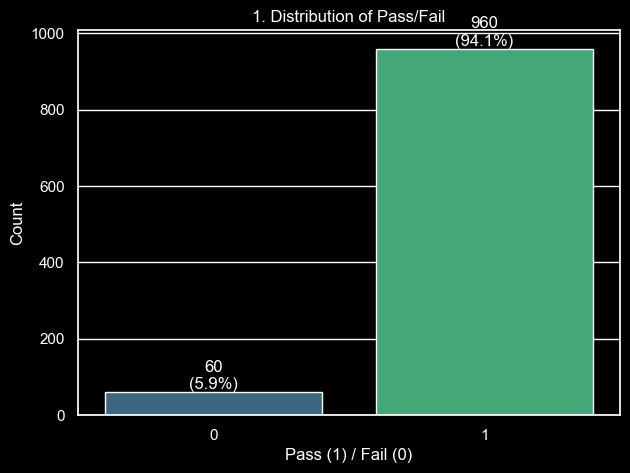

In [5]:
#  1. BIỂU ĐỒ PASS/FAIL

plt.figure(figsize=(7,5))
ax = sns.countplot(data=df, x='pass', hue='pass', palette='viridis', legend=False)

# Hiển thị số lượng + %
total = len(df)
for p in ax.patches:
    percent = 100 * p.get_height() / total
    ax.annotate(f"{int(p.get_height())}\n({percent:.1f}%)",
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')

plt.title("1. Distribution of Pass/Fail")
plt.xlabel("Pass (1) / Fail (0)")
plt.ylabel("Count")

plt.savefig("../screenshots/01_pass_fail.png", dpi=300, bbox_inches='tight')
plt.show()

## 1. Biểu đồ Pass/Fail

- Nhận xét:

    + Số lượng sinh viên PASS (1) áp đảo hoàn toàn với 960 mẫu (chiếm 94.1%), trong khi số lượng FAIL (0) rất ít, chỉ có 60 mẫu (chiếm 5.9%)
    + Dataset bị mất cân bằng (imbalanced data)
    + Nếu huấn luyện trực tiếp trên tập dữ liệu này, mô hình (model) sẽ bị thiên lệch (bias) và có xu hướng luôn dự đoán là PASS để đạt độ chính xác cao

- Kết luận:

    + Accuracy có thể không phản ánh đúng hiệu quả
    + Cần chú ý Recall cho lớp FAIL để đảm bảo mô hình nhận diện tốt những sinh viên có nguy cơ trượt

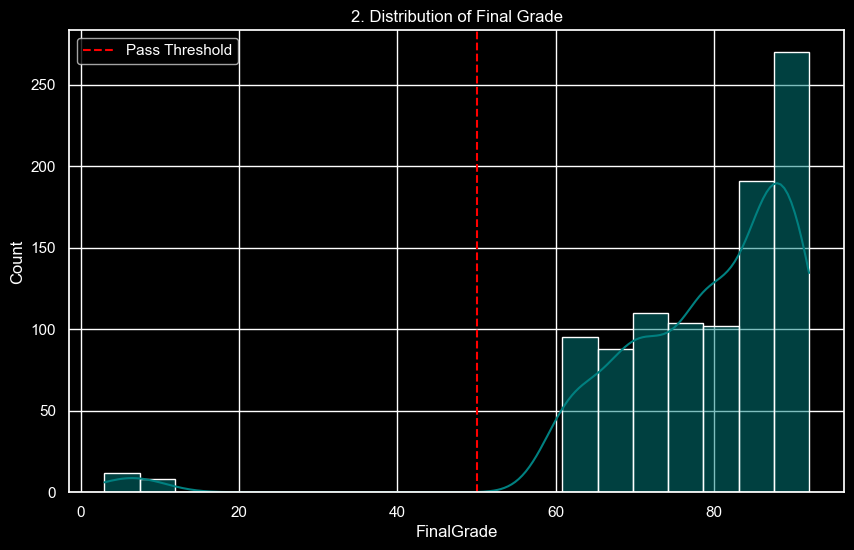

In [6]:
#  2. HISTOGRAM FINAL GRADE
plt.figure()
sns.histplot(df['FinalGrade'], bins=20, kde=True, color='teal')

plt.axvline(x=50, color='red', linestyle='--', label='Pass Threshold')
plt.title("2. Distribution of Final Grade")
plt.legend()

plt.savefig("../screenshots/02_final_grade.png", dpi=300, bbox_inches='tight')
plt.show()

## 2. Biểu đồ phân bố điểm (FinalGrade)

- Nhận xét:

    + Dữ liệu không tuân theo phân phối chuẩn mà bị lệch trái mạnh
    + Điểm số không tập trung ở mức trung bình mà tập trung dày đặc ở mức khá - giỏi (60 - 90+ điểm), với một đỉnh rất cao ở vùng tiệm cận 90
    + Đại đa số dữ liệu nằm bên phải đường "Pass Threshold" (mốc 50 điểm). Điều này hoàn toàn khớp với kết quả ở biểu đồ 1 (lớp PASS chiếm tới 94.1%)
    + Có một nhóm rất nhỏ sinh viên có điểm cực kỳ thấp (vùng 0 - 10 điểm). Đây là các giá trị ngoại lệ (outliers) hoặc có thể là sinh viên bỏ thi/bỏ học

- Kết luận:

    + Dữ liệu không có phân phối chuẩn rõ ràng
    + Có thể cần model phi tuyến
    + Cần kiểm tra kỹ nhóm điểm 0 - 10 (Outliers). Nên phân tích xem đây là dữ liệu nhiễu (cần xóa) hay là thông tin quan trọng của nhóm sinh viên trượt

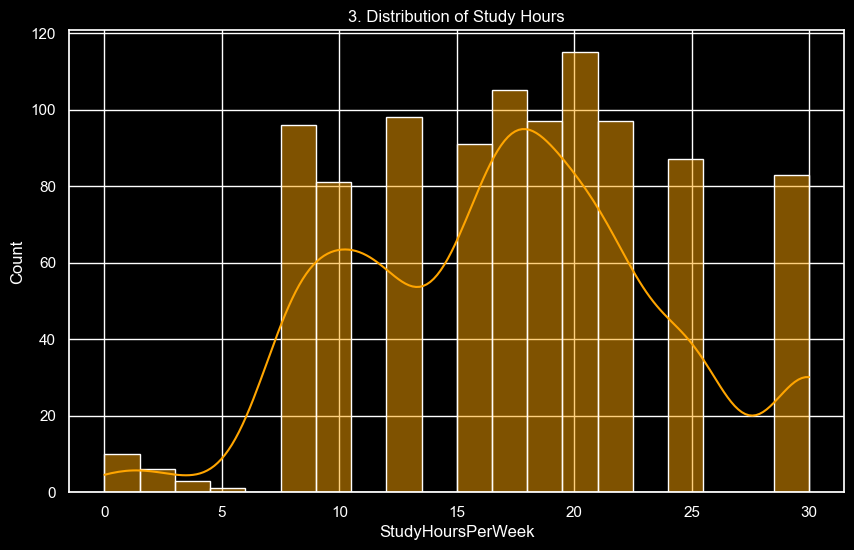

In [7]:
#  3. HISTOGRAM STUDY HOURS

plt.figure()
sns.histplot(df['StudyHoursPerWeek'], bins=20, kde=True, color='orange')

plt.title("3. Distribution of Study Hours")

plt.savefig("../screenshots/03_study_hours.png", dpi=300, bbox_inches='tight')
plt.show()

## 3. Biểu đồ phân bố giờ học (StudyHoursPerWeek)

- Nhận xét:

    + Dữ liệu có độ phân tán cao, trải dài trên một phổ rất rộng từ 0 đến khoảng 30 giờ/tuần
    + Phần lớn sinh viên dành từ 8 đến 25h/tuần cho việc học
    + Phân phối có dấu hiệu đa đỉnh thay vì chuẩn hóa: Đỉnh cao nhất nằm ở quanh mức 18 - 20 giờ/tuần, và một đỉnh phụ khác nằm ở mức khoảng 10 - 12 giờ
    + Rất hiếm sinh viên học dưới 5 giờ/tuần

- Kết luận:

    + Dữ liệu có sự phân tán
    + Có khả năng tồn tại outlier

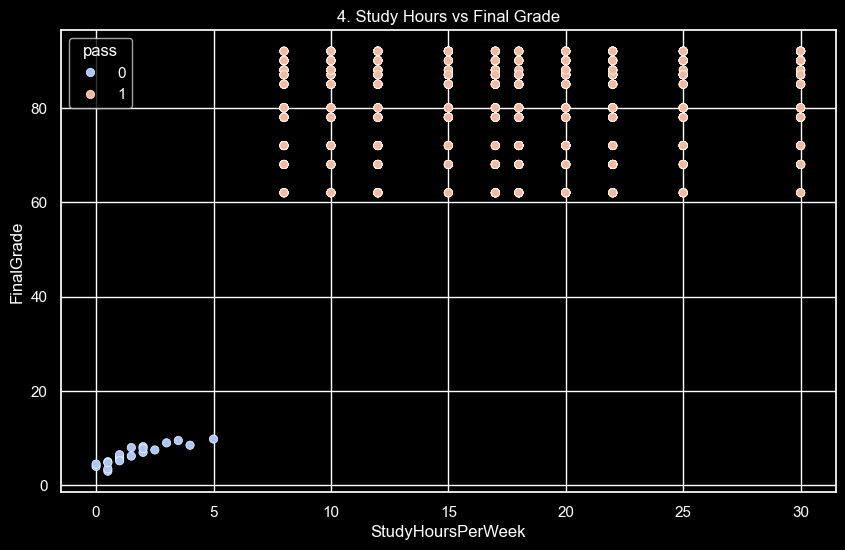

In [9]:
# 4. SCATTER: STUDY HOURS vs FINAL GRADE

plt.figure()
sns.scatterplot(data=df, x='StudyHoursPerWeek', y='FinalGrade', hue='pass', palette='coolwarm')

plt.title("4. Study Hours vs Final Grade")

plt.savefig("../screenshots/04_scatter.png", dpi=300, bbox_inches='tight')
plt.show()

## 4. Scatter: Study Hours vs Final Grade

- Nhận xét:

    + Có ranh giới rõ ràng giữa nhóm Đậu (Pass = 1, màu hồng) và nhóm Rớt (Pass = 0, màu xanh)
    + Mốc ~6 giờ học/tuần là một ranh giới cứng:
        + 100% sinh viên học dưới 6 giờ/tuần đều rớt (điểm < 20)
        + 100% sinh viên học từ 6 giờ/tuần trở lên đều đậu (điểm > 60)
    + Mối quan hệ trong nội bộ nhóm:
        + Nhóm FAIL (dưới 6h): Có sự tuyến tính nhẹ (học tăng lên một chút thì điểm rớt cũng nhích lên một chút)
        + Nhóm PASS (trên 6h): Mối quan hệ tuyến tính biến mất. Việc học 30 tiếng không đảm bảo điểm sẽ cao hơn người học 10 tiếng (các điểm phân tán dọc theo toàn bộ dải điểm từ 60 đến 90+)

- Kết luận:

    + StudyHours là một đặc trưng cực kỳ mạnh để dự đoán nhóm FAIL
    + Không cần thiết phải dùng các mô hình tuyến tính phức tạp cho đặc trưng này vì bản chất của nó là phân nhánh chứ không phải tuyến tính liên tục

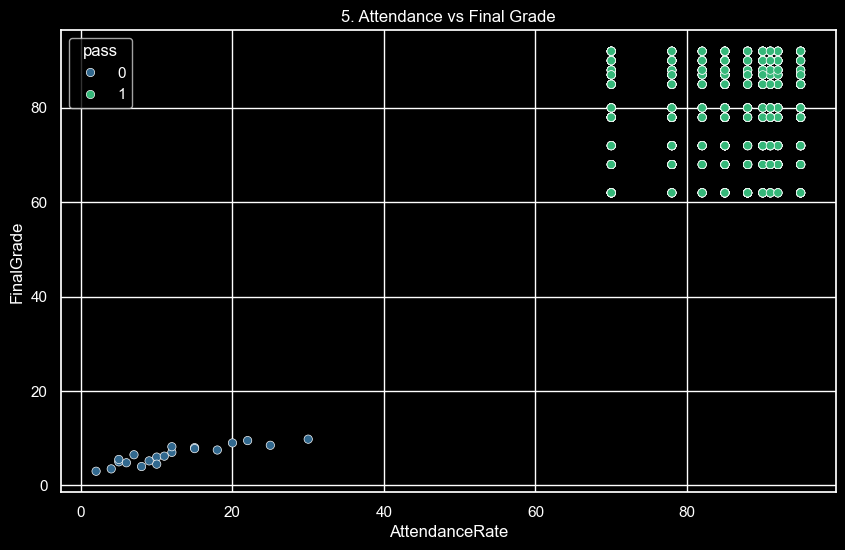

In [11]:
#  5. SCATTER: ATTENDANCE vs FINAL GRADE

plt.figure()
sns.scatterplot(data=df, x='AttendanceRate', y='FinalGrade', hue='pass', palette='viridis')

plt.title("5. Attendance vs Final Grade")

plt.savefig("../screenshots/05_attendance.png", dpi=300, bbox_inches='tight')
plt.show()

## 5. Scatter: Attendance vs Final Grade

- Nhận xét:

    + Có một vùng trống cực lớn ở giữa biểu đồ. Không có bất kỳ sinh viên nào có tỷ lệ điểm danh từ khoảng 35% đến 60%. Dữ liệu bị phân cực trầm trọng thành hai thái cực:
        + Thái cực 1 (FAIL - Màu xanh dương): Điểm danh dưới 35% $\rightarrow$ 100% rớt (điểm < 20)
        + Thái cực 2 (PASS - Màu xanh lá): Điểm danh trên 60% $\rightarrow$ 100% đậu (điểm > 60)
    + Ở nhóm FAIL, tỷ lệ điểm danh và điểm số có mối quan hệ tuyến tính đồng biến nhẹ

- Kết luận:

    + Attendance có ảnh hưởng tích cực
    + Nhưng không đảm bảo chắc chắn PASS

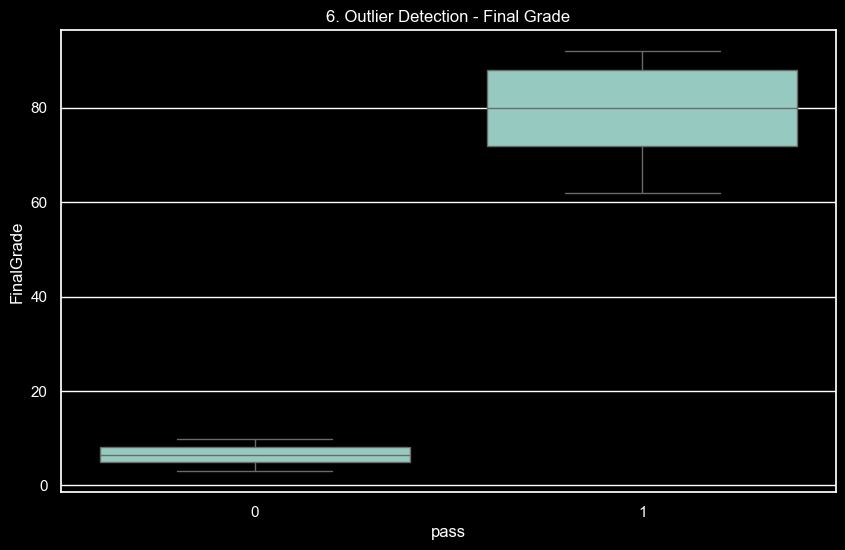

In [12]:
#  6. BOXPLOT (OUTLIER DETECTION)

plt.figure()
sns.boxplot(data=df, x='pass', y='FinalGrade')

plt.title("6. Outlier Detection - Final Grade")

plt.savefig("../screenshots/06_boxplot.png", dpi=300, bbox_inches='tight')
plt.show()

## 6. Boxplot (Outlier Detection – FinalGrade)

- Nhận xét:

    + Biểu đồ hoàn toàn không có các chấm ngoại lệ
    + Nhóm FAIL dồn hết xuống dưới (< 10 điểm), nhóm PASS nằm hẳn phía trên (> 60 điểm), khoảng giữa hoàn toàn trống rỗng

- Kết luận:

    + Biểu đồ cho thấy nhãn pass được quyết định trực tiếp bởi FinalGrade

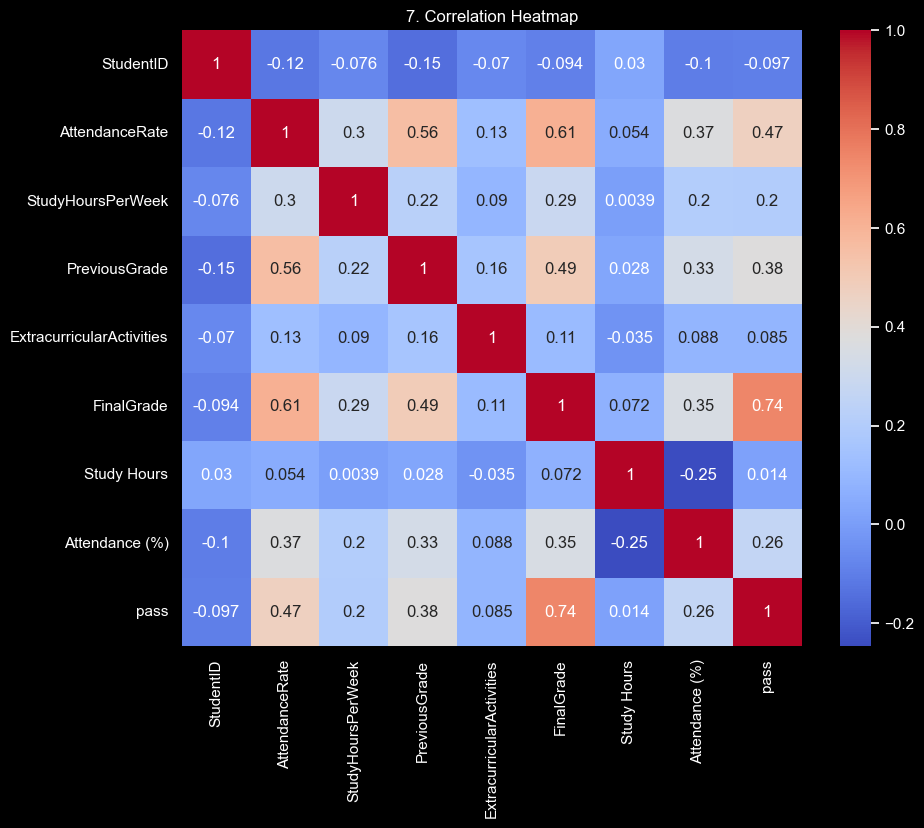

In [13]:
# 7. HEATMAP CORRELATION
plt.figure(figsize=(10,8))

numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("7. Correlation Heatmap")

plt.savefig("../screenshots/07_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()


## 7. Heatmap Correlation

- Nhận xét:

    + Các biến có tương quan khá thấp với nhau
    + FinalGrade có tương quan rất cao với pass (0.74)

- Kết luận:

    + Bài toán có thể không tuyến tính
    + Nên sử dụng model như:
    + RandomForest
    + SVM

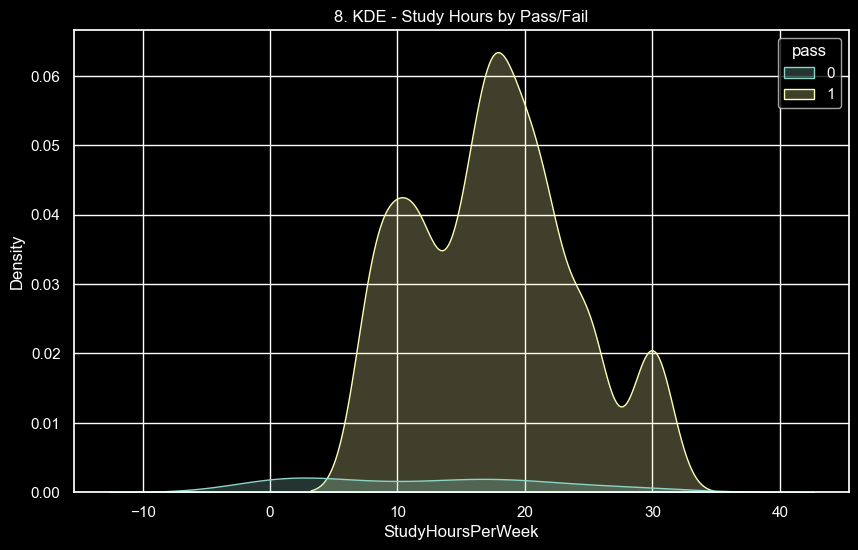

In [14]:
# 8. KDE PLOT (SO SÁNH PASS/FAIL)
plt.figure()
sns.kdeplot(data=df, x='StudyHoursPerWeek', hue='pass', fill=True)

plt.title("8. KDE - Study Hours by Pass/Fail")

plt.savefig("../screenshots/08_kde.png", dpi=300, bbox_inches='tight')
plt.show()

## 8. KDE Plot (StudyHours theo Pass/Fail)

- Nhận xét:

    + Hai phân phối này tách biệt gần như tuyệt đối ở mốc ~5-6 giờ học
    + Đường màu xanh (nhóm FAIL) bị xẹp lép ở sát góc trái (0-5 giờ) là do số lượng sinh viên rớt quá ít (60 sinh viên) so với nhóm PASS (960 sinh viên). Vùng diện tích màu vàng (nhóm PASS) hoàn toàn bắt đầu từ mốc > 6 giờ trở đi

- Kết luận:

    + Biểu đồ KDE này hoàn toàn khớp và củng cố lại phát hiện từ biểu đồ Scatter số 4 trước đó: Cứ học dưới 6 tiếng là rớt.

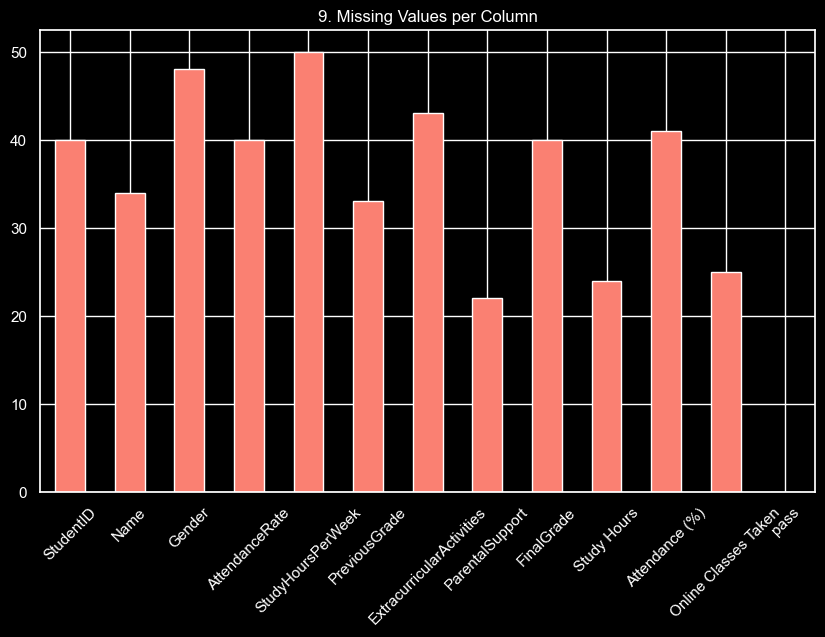

In [15]:
# 9. MISSING VALUES (BAR CHART)
plt.figure()

missing = df.isnull().sum()
missing.plot(kind='bar', color='salmon')

plt.title("9. Missing Values per Column")
plt.xticks(rotation=45)

plt.savefig("../screenshots/09_missing.png", dpi=300, bbox_inches='tight')
plt.show()


## 9. Missing Values

- Nhận xét:

    + Nhiều cột có giá trị bị thiếu

-  Kết luận:

    + Cần xử lý missing values trước khi train:
    + Numeric → mean
    + Categorical → mode

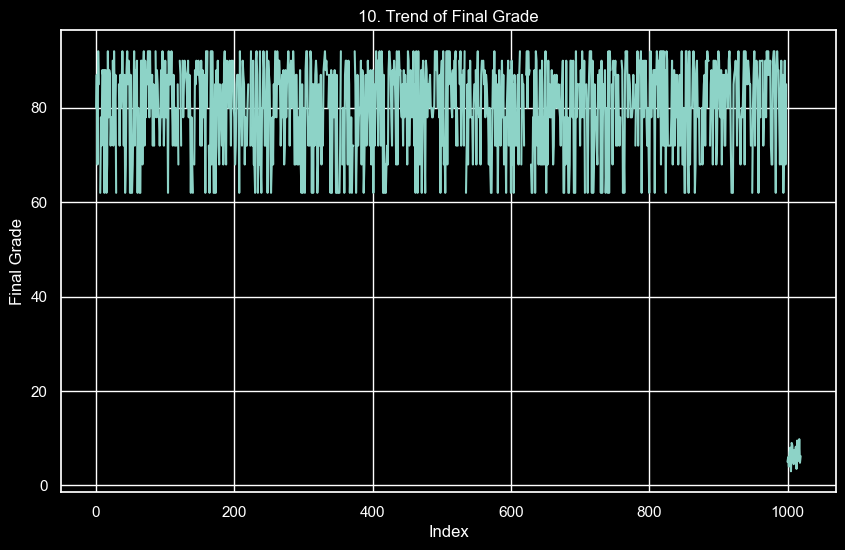

In [16]:
# 10. LINE PLOT (XU HƯỚNG ĐIỂM)
plt.figure()
plt.plot(df['FinalGrade'].values)

plt.title("10. Trend of Final Grade")
plt.xlabel("Index")
plt.ylabel("Final Grade")

plt.savefig("../screenshots/10_line.png", dpi=300, bbox_inches='tight')
plt.show()

## 10. Line Plot (Xu hướng điểm)

- Nhận xét:

    + Nhóm đậu (PASS) nằm dồn hết ở đầu, nhóm rớt (FAIL) bị đẩy hết xuống 60 dòng cuối cùng

- Kết luận:

    + Nếu chỉ cắt theo thứ tự trên xuống, tập Train sẽ chứa 100% sinh viên PASS (mô hình không biết nhóm FAIL là gì) và tập Test toàn sinh viên FAIL, khiến mô hình bị hỏng hoàn toàn
    + Bắt buộc phải xáo trộn dữ liệu trước khi chia tập Train/Test

_TỔNG KẾT EDA:_

- Dataset bị mất cân bằng giữa PASS và FAIL
- Các feature có tương quan thấp với target
- Không có mối quan hệ tuyến tính rõ ràng

=> Cần sử dụng model mạnh như RandomForest

BƯỚC 3: TIỀN XỬ LÝ DỮ LIỆU

In [17]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.preprocessing import preprocess_data
import pandas as pd

df = pd.read_csv("../data/student_performance.csv")

X_train, X_test, y_train, y_test, preprocessor = preprocess_data(df)

_Data Preprocessing_

Các bước tiền xử lý được thực hiện trong file 'preprocessing.py':

- Loại bỏ các cột không cần thiết
- Xử lý missing values:
  - Numeric → mean
  - Categorical → mode
- Encode categorical bằng LabelEncoder
- Chia train/test với stratify
- Chuẩn hóa dữ liệu bằng StandardScaler

BƯỚC 4: XÂY DỰNG MÔ HÌNH

Nhận xét model:

- Accuracy cao (~96%) ở tất cả các model
- Có thể do:
  - Dataset bị mất cân bằng (PASS chiếm đa số)
  - Feature có liên quan mạnh đến kết quả

=> Accuracy có thể chưa phản ánh đúng hiệu quả model
=> Cần xem thêm Recall và Confusion Matrix

Chọn model tốt nhất

- Các model đều có accuracy tương đương (~96%)
- Chọn RandomForest làm model chính vì:
  - Xử lý tốt dữ liệu phi tuyến
  - Ổn định hơn Logistic Regression

BƯỚC 5: Đánh giá và tinh chỉnh

Sau khi thực hiện tinh chỉnh siêu tham số bằng Grid Search và áp dụng kỹ thuật cân bằng dữ liệu SMOTE, mô hình Random Forest đã cải thiện đáng kể khả năng nhận diện lớp thiểu số (FAIL). Chỉ số F1-score của lớp FAIL tăng từ 0.00 lên 0.67, với Precision đạt 1.00. Điều này chứng minh mô hình có độ tin cậy tuyệt đối khi phát hiện sinh viên có nguy cơ rớt môn, đáp ứng tốt mục tiêu của bài toán đề ra."

BƯỚC 6: LƯU MÔ HÌNH

- Mô hình được lưu bằng joblib
- Đồng thời lưu scaler để xử lý dữ liệu mới

- Sau khi load lại:
  - Model vẫn dự đoán được kết quả
  - Điều này chứng minh mô hình có thể tái sử dụng